# Vivino Analysis:
This is brief analysis of a partial wine dataset from vivino. Partial in this case means that we only have access to high end wines, at the top of the price distributions. It also means, we're talking about largely delicious wines... 

## Table of Contents
- [Initialising](#initialising)
- [Thinking](#thinking)
  - [Highlighted Top 10 Wines](#selected-top-10)
  - [Marketing budget](#marketing-budget)
  - [Winery Awards](#winery-awards)
  - [Most Common Grapes ](#most-common-grapes)
  - [Country Leaderboard](#country-leaderboard)
  - [VIP Recommendation](#vip-recommendation)


## Set Up : *...Initialising...*  
Setting up imports and connecting to the database

### Data cleaning: *...loading...*  
Data is clean. The only problem that surfaced was that we have a list of winery names, only four of those actually appear in the wines that we have. That is to say, we have a lot of wineries id numbers from the wines tables that do no appear in the winery table. 
  
## Analysis : *...Thinking...*  
The most important factors are *price and the average user rating* of a wine. Let's start by looking at those.   
💡 Wines can have several vintages. A vintage belongs to a single wine. think of a vintage as "Year YYYY edition" of a given wine.  
- 47 wines and 246 vintages have a rating of 4.7 and above. It's a small set.    
 
- 📊 Looking at price distributions of all wines: Huge spread, starting around 20, going as high as 10k. (Nothing Under 20€ except for small bottles of 375 ml).  
     
- 📊 Looking at the distribution of wine ratings, we can see a largely normal distribution. However, the dataset ratings begin at 4.1 going up to 4.9. This is an artifact of the dataset itself.  
  
- 📊 Looking at average price per rating, we get the expected result: higher price for higher ratings. The highest rating (4.9) dips, but that's a small sample artifact.  
  
- 📊 Looking at average number of ratings per rating (with average price for reference). That is to say: for the all the 4.4 rated vintages, what is the average number of time the rating was given? We would expect a downward slope: as we've seen, higher rated wines are more expensive, therefore, theyy should also be less often rated, since they more difficult to obtain.     
However, we get something interesting: the 4.5 rating is the forgotten group.  


## Exercise questions:

### [Highlighted Top 10 Wines](#selected-top-10) 📋
How should we select 10 wines amongs 2000 of them? Here is how I approached the problem.
We want to showcase 10 wines, *to increase sales*. Price is a big factor here.
I decided to create a balanced selection for several price categories.
In some cases I created a "bang for buck" feature which I used for relative rankings. 

### [Marketing budget](#marketing-budget) *Most users wins* 
US, France, and Italy. They have the most users, all three have a very high number of wines and wineries.

### [Winery Awards](#winery-awards) *Branding Matters*. 📋
France and italy dominate for pure quality.  
When price is taken into account, other countries start to emerge : south africa and hungary. This confirms the general wisdom and intuition. France and Italy are well known for the quality of their wines, and the data confirms it. But reputation has a price for the consumer: those wines are expensive. Other nations, not as well known for the quality of their production must compete on price to attract customers to their product. 

💡 Region awards would be a nice addition to that

### [Most Common Grapes](#most-common-grapes) 📋
Cabernet Sauvignon, Chardonnay, Pinot Noir. 


### [Flavour Profile Analysis](#flavor-profile-analysis)  📋
The cluster identified was champagne. 

### [Country Leaderboard](#country-leaderboard). 📊
Big differences between vintages and wine averages. Not sure why to be honest. 

### [VIP Recommendation](#vip-recommendation) 📋
Scarecrow Cabernet Sauvignon 2015. Because VIP, so money is no object. 


Todo:
fill in the sections above that have no summary.

## Initialising

In [1]:
## Imports
import sqlite3

# For charting:
import pandas as pd 
import matplotlib.pyplot as plt

# paths
from pathlib import Path





In [2]:
# Connecting to db and loading the database
#db_path = "../data/vivino.db"
%load_ext sql
%sql sqlite:///../data/vivino.db

connexion = sqlite3.connect("../data/vivino.db")
cursor = connexion.cursor()


## Usefull info lines: 
# %sql?
# %sqlcmd tables
# %sqlcmd columns -t countries

Tip: You may define configurations in /Users/jkzmr/Developer/becode/vivinodb/pyproject.toml or /Users/jkzmr/.jupysql/config.

Did not find user configurations in /Users/jkzmr/Developer/becode/vivinodb/pyproject.toml.

Connecting to 'sqlite:///../data/vivino.db'

Running query in 'sqlite:///../data/vivino.db'

<Axes: xlabel='ratings_average'>

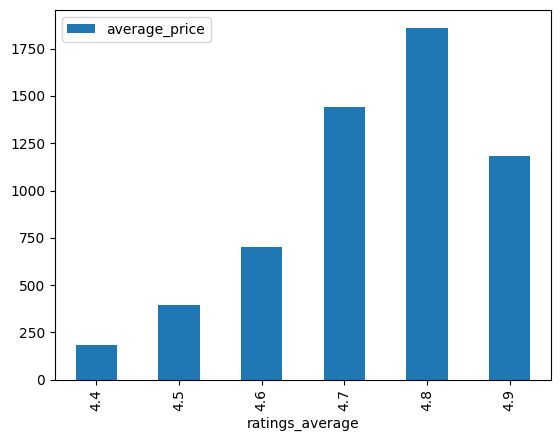

In [3]:
## Syntax ref for later : 
# This syntax works: 

with open("../queries/cheapest_wines.sql", encoding="utf-8") as f:
    query = f.read()

df = pd.read_sql_query(query, connexion)
#df

result = %sql SELECT ratings_average, AVG(price_euros) AS average_price FROM vintages WHERE ratings_average > 4.0 GROUP BY ratings_average ORDER BY ratings_average ASC
df = result.DataFrame()
df.plot.bar(x='ratings_average', y='average_price')


#df.plot(kind="box", y="price_euros", figsize=(6, 6), sharex=False, legend=False)
#df.plot(kind="box", y="price_euros", ylim=(0,1000), figsize=(6, 6), sharex=False, legend=False)
#df.plot(subplots=True, kind="box", layout=(2, 1), figsize=(6, 12), y="price_euros", ylim=(0,1000),  legend=False)

## This works too, but the results aren't well displayed: no column names
#results = cursor.execute(query).fetchall()
#results
#print(results)


## Thinking:

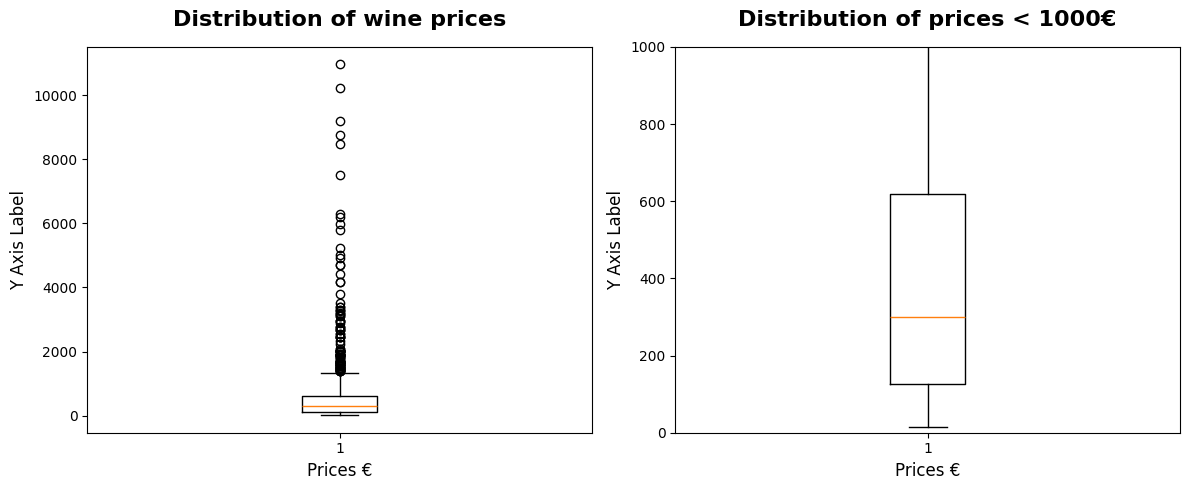

In [4]:
## Visualizing wine prices
## Data
with open("../queries/cheapest_wines.sql", encoding="utf-8") as f:
    query = f.read()
df = pd.read_sql_query(query, connexion)

## Plotting:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5),  gridspec_kw={"width_ratios": [1, 1]})  # left is 2x wider than right

axes[0].boxplot(df["price_euros"], vert=True)          
    
axes[1].boxplot(df["price_euros"], vert=True)              
axes[1].set_ylim(0,1000)

# Title and Labels
axes[0].set_title("Distribution of wine prices", fontsize=16, fontweight="bold", pad=15)
axes[0].set_xlabel("Prices €", fontsize=12)
axes[0].set_ylabel("Y Axis Label", fontsize=12)

axes[1].set_title("Distribution of prices < 1000€", fontsize=16, fontweight="bold", pad=15)
axes[1].set_xlabel("Prices €", fontsize=12)
axes[1].set_ylabel("Y Axis Label", fontsize=12)
fig.tight_layout()   
plt.show()

<Axes: title={'center': "'ratings_average' from 'wines'"}, xlabel='ratings_average', ylabel='Count'>

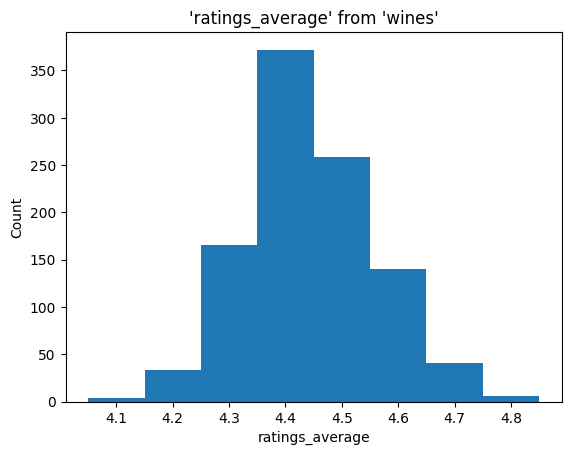

In [5]:
%sqlplot histogram --table wines --column ratings_average --bins 8


<Axes: title={'center': 'Avg price per rating for vintages'}, xlabel='ratings_average'>

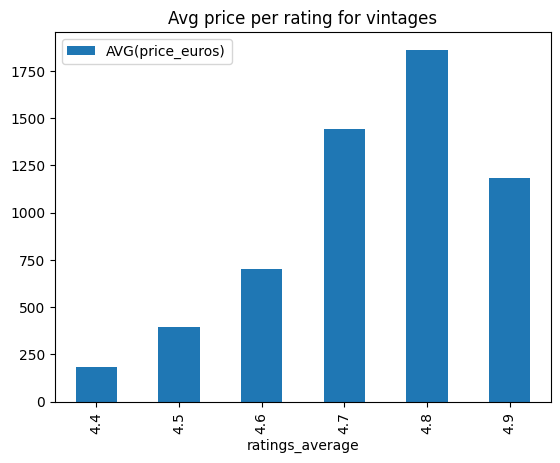

In [6]:
## Average price per rating for vintages
with open("../queries/avg_price_by_rating.sql", encoding="utf-8") as f:
    query = f.read()
    
df = pd.read_sql_query(query, connexion)
df.plot.bar(x="ratings_average", y="AVG(price_euros)", title="Avg price per rating for vintages")

Running query in 'sqlite:///../data/vivino.db'

<Axes: xlabel='ratings_average'>

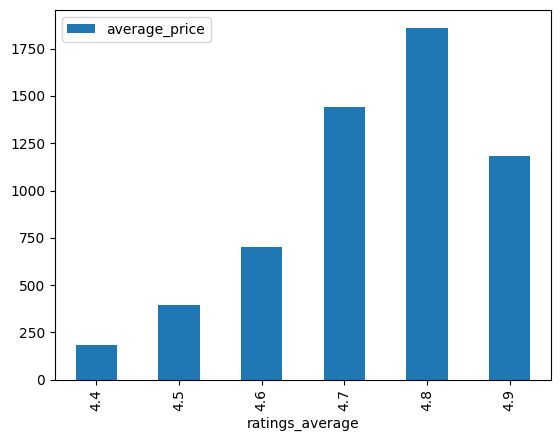

In [7]:
## Average Prices by ratings : charted
result = %sql SELECT ratings_average, AVG(price_euros) AS average_price FROM vintages WHERE ratings_average > 4.0 GROUP BY ratings_average ORDER BY ratings_average ASC
df = result.DataFrame()
df.plot.bar(x='ratings_average', y='average_price')

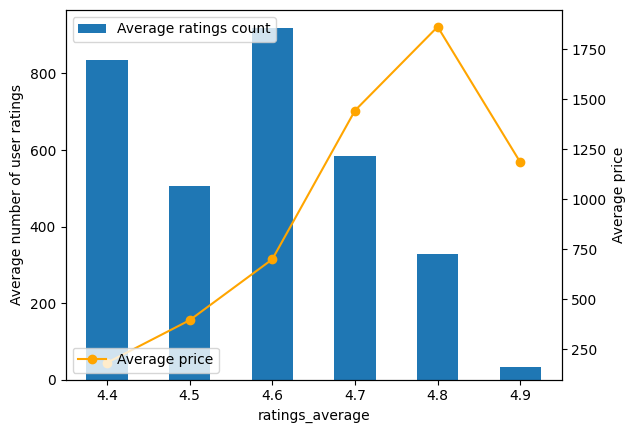

In [8]:
## Plotting average number of ratings per rating (and showing average prices for each rating)

with open("../queries/average_rating_count_by_rating.sql", encoding="utf-8") as f:
    query = f.read()

df = pd.read_sql_query(query, connexion)

plot_df = df.set_index("ratings_average")

ax = plot_df["average_ratings_count"].plot.bar(label="Average ratings count")
ax2 = ax.twinx()

ax2.plot(range(len(plot_df)), plot_df["average_price"], color="orange", marker="o", label="Average price")

ax.set_ylabel("Average number of user ratings")
ax2.set_ylabel("Average price")
ax.set_xticklabels(plot_df.index, rotation=0)

ax.legend(loc="upper left")
ax2.legend(loc="lower left")

# y_label="average ratings count",
# legend="average_price"

### Selected Top 10  
How should we select 10 wines amongs 2000 of them? Here is how I approached the problem.
We want to showcase 10 wines, *to increase sales*. Price is a big factor here.
I decided to create a balanced selection for several price categories, making sure to have a variety of origins, some reds, some whites. I also exculded any vintage having less than 200 user ratings, to preserve statistical significance through wisdom of the crowd.

5X Great deal: (<30€) (2 white, 3 reds)
3X Excellent: (<50€) 4.5 (1 white, 2 reds)
2X Amazing: under 100
1X Luxury : A few exceptionnal bottles for their price

Improvements:
We could create a feaute that merges average rating and price, into a balanced bang_for_buck ratings. 
Take the ratings divide by adjusted price. Boom. Normalise maybe,

**Great Deals:**
| Wine ID | Vintage ID | Rating | Country        | Region                    | Price        | RED/WHITE | Name |
|---------|------------|--------|----------------|---------------------------|--------------|-----------|------|
| 6741558 | 160094800  | 4.5    | Italie         | Primitivo di Manduria *** | 24.0         | RED       | Name |
| 3783366 | 152008500  | 4.4    | Moldavie       | Moldova                   | 46.77 (1.5L) | WHITE     | Name |
| 16504   | 159319855  | 4.4    | Argentine      | Mendoza                   | 26.0         | RED       | Name |
| 1627830 | 146295008  | 4.4    | Afrique du Sud | Stellenbosch              | 27.0         | RED       | Name |
| 2246136 | 156124899  | 4.4    | Chili          | Maipo Valley              | 30           | WHITE     | Name |


**Excellent:**
| Wine ID | Vintage ID | Rating | Country  | Region                | Price | RED/WHITE | Name |
|---------|------------|--------|----------|-----------------------|-------|-----------|------|
| 1468452 | 127578652  | 4.5    | Moldavie | Moldova               | 31.0  | White     | Name |
| 11890   | 150263185  | 4.5    | Italie   | Primitivo di Manduria | 32.0  | Red       | Name |
| 7830543 | 163184376  | 4.5    | France   | Côtes-du-Rhône        | 35.0  | Red       | Name |


**Amazing**
| Wine ID | Vintage ID | Rating | Country | Region                              | Price | RED/WHITE | Name |
|---------|------------|--------|---------|-------------------------------------|-------|-----------|------|
| 1168085 | 25822713   | 4.6    | Italie  | Amarone della Valpolicella Classico | 75.0  | red       | Name |
| 66284   | 159338927  | 4.6    | US      | Napa Valley                         | 89.0  | Red       | Name |


**Luxury: A few exceptionnal bottles:**
| Wine ID | Vintage ID | Rating | Country | Region                 | Price | RED/WHITE | Name |
|---------|------------|--------|---------|------------------------|-------|-----------|------|
| 1175427 | 156110733  | 4.7    | Espagne | Ribera del Duero       | 180.0 | red       | Name |
| 81836   | 131862469  | 4.8    | Italie  | Brunello di Montalcino | 379.0 | Red       | Name |



In [9]:
## New top 10
with open("../queries/top_ten.sql", encoding="utf-8") as f:
    query = f.read()

df = pd.read_sql_query(query, connexion)
df

,wine_id,vintage_id,country_name,region_name,adjusted_price,ratings_average,name,ratings_count,price_euros,tannin,price_discounted_from,bottle_volume_ml,fizziness
0,81836,131862469,Italie,Brunello di Montalcino,379.0,4.8,Casanova di Neri Cerretalto Brunello di Montal...,175,379.00,3.650135,None,750,NaN
1,84065,2890763,Italie,Amarone della Valpolicella Classico,425.0,4.8,Quintarelli Giuseppe Amarone della Valpolicell...,444,425.00,2.311430,None,750,NaN
2,1194532,2423072,Italie,Veneto,555.0,4.8,Quintarelli Giuseppe Veneto Alzero Cabernet 2009,208,555.00,2.936496,None,750,NaN
3,82203,127064316,Italie,Barolo,705.0,4.8,Giacomo Conterno Barolo Cascina Francia 2016,214,705.00,4.331374,None,750,NaN
4,8023,103459705,États-Unis,Napa Valley,745.0,4.8,Colgin IX Estate Red 2016,131,745.00,3.635063,None,750,NaN
5,1153863,14207721,France,Sauternes,811.0,4.8,Château d'Yquem Sauternes 2015,763,811.25,NaN,None,750,NaN
6,1274124,150679517,France,Montrachet Grand Cru,812.0,4.8,Joseph Drouhin Montrachet Grand Cru Marquis de...,137,811.80,NaN,None,750,NaN
7,1153863,150313476,France,Sauternes,833.0,4.8,Château d'Yquem Sauternes 2017,334,832.50,NaN,None,750,NaN
8,1611255,14187320,États-Unis,Rutherford,1559.0,4.8,Scarecrow Cabernet Sauvignon 2015,243,1558.75,3.393993,None,750,NaN
9,1655970,2641965,France,Pauillac,1686.0,4.8,Château Latour Grand Vin Pauillac (Premier Gra...,920,1686.25,4.140877,None,750,NaN


### Highlight 10 wines : older selection

Selection: 10 bottles for every budget: (+ a few for dreaming...)
5X Great deal: 4.4 (2 white, 3 reds)
3X Excellent: 4.5
2X Amazing: 4.6
1X Luxury : 4.7 and up


**WINNERS SO FAR** There are too much, I'll make an executive decision later

| Wine ID | Vintage ID | Rating | Country   | Region                | Price           | RED/WHITE       | Name                                                                              |
|---------|------------|--------|-----------|-----------------------|-----------------|-----------------|-----------------------------------------------------------------------------------|
| 1129440 | 160148272  | 4.4    | Italy     | Primitivo di Manduria | 23(re-adjusted) | Red             | Luccarelli Old Vines Primitivo di Manduria 2019                                   |
| 3783366 | 152008500  | 4.4    | Moldavie  | Moldova               | 46.77 (1.5l)    | White           | Gitana Saperavi 2017                                                              |
| 16504   | 159319855  | 4.4    | Argentina | Mendoza               | 25.99           | Red             | Rutini Malbec 2019                                                                |
| 2246136 | 156124899  | 4.4    | Chili     | Maipo Valley          | 29.95           | White           | El Principal Memorias 2018                                                        |
| 5364329 | 163053458  | 4.4    | Italy     | Abruzzo               | 23.9            | Red             | Farnese Cinque Autoctoni Collection Limited Release 2020                          |
| 6741558 | 160094800  | 4.5    | Italy     | Primitivo di Manduria | 23.95           | Red             | Vigneti del Salento Vigne Vecchie Gold Series Leggenda Primitivo di Manduria 2019 |
| 1468452 | 127578652  | 4.5    | Moldavie  | Moldova               | 61.29 (1.5L)    | White           | Gitana Lupi Rezerva 2016                                                          |
| 7830543 | 163184376  | 4.5    | France    | Côtes-du-Rhône        | 34.95           | Red             | Château de Gourdon Terrasse à l'Ombre Côtes du Rhône 2018                         |
| 18323   | 2590138    | 4.6    | Chili     | Colchagua Valley      | 89.0            | Red             | Casa Silva Altura 2012                                                            |
| 1301256 | 8738731    | 4.6    | France    | Champagne             | 199.0           | White-Sparkling | Deutz Amour de Deutz Millésimé Brut Champagne 2011                                |
| 1175427 | 86137513   | 4.7    | Espagne   | Ribera del Duero      | 202.2           | Red             | ** Vega Sicilia Valbuena 5º 2016                                                  |
| 5194    | 159405688  | 4.7    | US        | Rutherford            | 260             | Red             | ** Quintessa Rutherford 2019                                                      |
| 84065   | 2890763    | 4.8    | Italy     | ?                     | 425             | Red             | ** Quintarelli Giuseppe Amarone della Valpolicella Classico 2013                  |


**REMARKS**
12 wines have a discount; not a big deal.

Trying to see the wines that appear more than once:


In [10]:
%%sql
SELECT wines.id, wines.name, vintages.wine_id, count(wines.id)
FROM wines
JOIN vintages on wines.id = vintages.wine_id
GROUP BY wines.id
HAVING count(wines.id) >=2 -- AND count(wines.id) < 7 
ORDER BY count(wines.id) DESC
LIMIT 10

Running query in 'sqlite:///../data/vivino.db'

id,name,wine_id,count(wines.id)
22447,Bolgheri Superiore,22447,26
5078,Sassicaia,5078,25
2446729,Toscana,2446729,24
3908,Pauillac (Premier Grand Cru Classé),3908,19
1558589,Brunello di Montalcino,1558589,17
82698,Brunello di Montalcino Riserva,82698,16
66104,Barbaresco,66104,16
1652,Tignanello,1652,16
1152755,Pessac-Léognan (Premier Grand Cru Classé),1152755,15
1127795,Château Margaux (Premier Grand Cru Classé),1127795,14


### Marketing budget
We have a marketing budget, where should we spend it?
US, France, and Italy. They have the most users, all three have a very high number of wines and wineries.



In [11]:
with open("../queries/user_count_by_country.sql", encoding="utf-8") as f:
    query = f.read()

df = pd.read_sql_query(query, connexion)
df


,code,name,regions_count,users_count,wines_count,wineries_count
0,us,États-Unis,362,12273684,204060,28145
1,fr,France,1306,5973301,422503,67553
2,it,Italie,563,4270717,274658,42399
3,de,Allemagne,236,2549989,164533,13643
4,es,Espagne,152,2264396,102662,18026
5,ch,Suisse,73,1601799,33656,3849
6,pt,Portugal,93,1123535,39847,5834
7,au,Australie,120,1022965,90954,13946
8,ar,Argentine,41,629532,36121,5339
9,cl,Chili,41,326757,41191,5785


### Winery awards
- We would like to give awards to the best wineries. Come up with 3 relevant ones. Which wineries should we choose and why? Be creative ;)

Two ways: 
1/ just the best : highest rated wines minimum 5 vintages
2/ bang for buck: wineries that offer the best bang for buck

❗ Wineries are filtered: only those having *more than 5 vintages are considered*.

Best Bang for buck Wineries id's:  4108, 3139, 11096, 60883, 1583, 1447, 1296, 1446, 1806, 2170,
| Winery_id | Region              | Country        |
|-----------|---------------------|----------------|
| 4108      | Paarl               | Afrique du Sud |
| 3139      | Tokaj               | Hongrie        |
| 11096     | Trentino-Alto Adige | Italy          |
(The names of those wineries is not available in the database.)


Best wineries for quality: 82979, 12630, 8028 (The names of those wineries is not available in the database.)
| Winery_id | Region    | Country |
|-----------|-----------|---------|
| 82979     | Toscana   | Italy   |
| 12630     | Pomerol   | France  |
| 8028      | Sauternes | France  |



In [12]:
## Best wineries for quality
with open("../queries/best_wineries.sql") as f:
    query = f.read()
    
df = pd.read_sql_query(query, connexion)
df


,wine_id,vintage_id,count,wine_average,winery_id,vintage_average
0,2446729,6410902,24,4.7,82979,4.700000
1,1166837,1308545,6,4.7,12630,4.700000
2,1153863,1398100,9,4.7,8028,4.733333
3,89750,108888,13,4.7,1852,4.330769
4,87552,105812,9,4.7,1523,4.677778
5,81836,1125282,6,4.7,1446,4.683333
6,1911534,1682257,6,4.6,1368,4.650000
7,1684223,3009429,10,4.6,64252,4.630000
8,1655970,2610998,10,4.6,2107,4.660000
9,1320744,1867561,7,4.6,4047,4.642857


In [13]:
## Winery awards: Bang for Buck
with open("../queries/best_wineries_bang_for_buck.sql", encoding="utf-8") as f:
    query = f.read()

df = pd.read_sql_query(query, connexion)
df


,winery_id,country,region,bang_for_buck,avg_price,bottle_volume_ml,count_vintages,ratings_average
0,4108,Afrique du Sud,Paarl,0.072973,62.0,750,6,4.5
1,3139,Hongrie,Tokaj,0.041992,75.0,500,7,4.6
2,11096,Italie,Trentino-Alto Adige,0.038411,147.0,1500,8,4.4
3,60883,Italie,Amarone della Valpolicella Classico,0.026378,202.0,750,6,4.5
4,1583,Italie,Amarone della Valpolicella Classico,0.022250,200.0,750,6,4.5
5,1447,Italie,Barbaresco,0.018678,238.0,750,12,4.4
6,1296,États-Unis,Napa Valley,0.018464,301.0,750,6,4.6
7,1446,Italie,Brunello di Montalcino,0.018063,275.0,750,18,4.5
8,1806,Italie,Barolo,0.016395,272.0,750,9,4.3
9,2170,Italie,Toscana,0.014597,339.0,750,10,4.4


In [14]:
## Winery awards : best bang for buck
with open("../queries/best_wineries_bang_for_buck.sql", encoding="utf-8") as f:
    query = f.read()

df = pd.read_sql_query(query, connexion)
df
#best_wineries = df["winery_id"].to_list()
#print(best_wineries) # -->  Best Bang for buck Wineries id's:  4108, 3139, 11096, 60883, 1583, 1447, 1296, 1446, 1806, 2170,

,winery_id,country,region,bang_for_buck,avg_price,bottle_volume_ml,count_vintages,ratings_average
0,4108,Afrique du Sud,Paarl,0.072973,62.0,750,6,4.5
1,3139,Hongrie,Tokaj,0.041992,75.0,500,7,4.6
2,11096,Italie,Trentino-Alto Adige,0.038411,147.0,1500,8,4.4
3,60883,Italie,Amarone della Valpolicella Classico,0.026378,202.0,750,6,4.5
4,1583,Italie,Amarone della Valpolicella Classico,0.022250,200.0,750,6,4.5
5,1447,Italie,Barbaresco,0.018678,238.0,750,12,4.4
6,1296,États-Unis,Napa Valley,0.018464,301.0,750,6,4.6
7,1446,Italie,Brunello di Montalcino,0.018063,275.0,750,18,4.5
8,1806,Italie,Barolo,0.016395,272.0,750,9,4.3
9,2170,Italie,Toscana,0.014597,339.0,750,10,4.4


In [15]:
%%sql
SELECT 
winery_id,
countries.name AS country, 
regions.name AS region,
--round((price_euros / bottle_volume_ml)*750) AS adjusted_price,
(AVG(vintages.ratings_average) / AVG(round((price_euros / bottle_volume_ml)*750))) AS bang_for_buck,
round(AVG(vintages.price_euros)) AS avg_price, 
vintages.bottle_volume_ml
FROM vintages
JOIN wines ON wines.id = vintages.wine_id
JOIN regions ON regions.id =  wines.region_id
JOIN countries ON countries.code = regions.country_code
WHERE  vintages.ratings_count > 100 
GROUP BY wines.winery_id
ORDER BY bang_for_buck DESC

Running query in 'sqlite:///../data/vivino.db'

winery_id,country,region,bang_for_buck,avg_price,bottle_volume_ml
42463,Italie,Primitivo di Manduria,0.1875,24.0,750
7892,Italie,Abruzzo,0.18333333333333335,24.0,750
223950,Italie,Primitivo di Manduria,0.1795918367346939,24.0,750
13261,Italie,Barbera d'Asti,0.17600000000000002,33.0,1000
4009,Argentine,Mendoza,0.16923076923076924,26.0,750
40453,Italie,Marche,0.16603773584905662,27.0,750
3060,Afrique du Sud,Stellenbosch,0.16296296296296298,27.0,750
19992,Italie,Puglia,0.16181818181818183,28.0,750
52856,France,Sauternes,0.15714285714285717,14.0,375
55648,Italie,Primitivo di Manduria,0.156140350877193,44.0,1500


### Most Common Grapes 
- We would like to select wines that are easy to find all over the world. **Find the top 3 most common `grape` all over the world** and **for each grape, give us the the 5 best rated wines**.

**Most common grapes:** (queries/most_common_grapes.sql)

| grape_id | name               | wines_count |
|----------|--------------------|-------------|
| 2        | Cabernet Sauvignon | 801751      |
| 5        | Chardonnay         | 604208      |
| 14       | Pinot Noir         | 572334      |


**Best Wines per grape:** (queries/best_wines_per_grape.sql)
I only selected wines with more than 100 user ratings. 

*Cabernet Sauvignon*
| Grape name (id = 2) | Country | Ratings average | Wine Name                            | wine ID |
|---------------------|---------|-----------------|--------------------------------------|---------|
| Cabernet Sauvignon  | us      | 4.8             | Cabernet Sauvignon                   | 1611255 |
| Cabernet Sauvignon  | us      | 4.7             | IX Estate Red                        | 8023    |
| Cabernet Sauvignon  | es      | 4.8             | Mágico                               | 5806244 |
| Cabernet Sauvignon  | us      | 4.7             | Special Selection Cabernet Sauvignon | 66294   |
| Cabernet Sauvignon  | es      | 4.7             | Unico Reserva Especial Edición       | 66294   |

*Chardonnay*
| Grape name (id = 5) | Country | Ratings average | Wine Name                                   | id      |
|---------------------|---------|-----------------|---------------------------------------------|---------|
| Chardonnay          | it      | 4.8             | Amarone della Valpolicella Classico Riserva | 1187886 |
| Chardonnay          | us      | 4.8             | Cabernet Sauvignon                          | 1611255 |
| Chardonnay          | it      | 4.8             | Fratini Bolgheri Superiore                  | 6534388 |
| Chardonnay          | us      | 4.7             | IX Estate Red                               | 8023    |
| Chardonnay          | us      | 4.7             | Special Selection Cabernet Sauvignon        | 66294   |


*Pinot Noir*
| Grape name (id = 14) | Country | Ratings average | Wine Name                            | id      |
|----------------------|---------|-----------------|--------------------------------------|---------|
| Pinot Noir           | us      | 4.8             | Cabernet Sauvignon                   | 1611255 |
| Pinot Noir           | us      | 4.7             | IX Estate Red                        | 8023    |
| Pinot Noir           | us      | 4.7             | Special Selection Cabernet Sauvignon | 66294   |
| Pinot Noir           | fr      | 4.7             | Collection                           | 79633   |
| Pinot Noir           | fr      | 4.7             | Clos du Mesnil                       | 79635   |





### Flavor profile analysis: 
- We have detected that a big cluster of customers like a specific combination of tastes. We have identified a few `primary` `keywords` that match this. We would like you to **find all the wines that have those keywords**. To ensure the accuracy of our selection, ensure that **more than 10 users confirmed those keywords**. Also, identify the `group_name` related to those keywords.

*Keywords:* coffee, toast, green apple, cream, citrus, 

**Group names:**
coffee = oak
toast = non-oak
green apple = tree_fruit
cream = microbio
citrus = citrus_fruit


**Results**: *(almost) all champagnes*:

| Wine Name                                          | wine_id | Champagne: |
|----------------------------------------------------|---------|------------|
| La Grande Année Brut Champagne                     | 18931   |            |
| Cristal Brut Champagne (Millésimé)                 | 74304   |            |
| Belle Epoque Brut Champagne                        | 79162   |            |
| Vintage                                            | 79631   |            |
| La Grande Dame Brut Champagne                      | 79836   |            |
| Brut Champagne                                     | 86684   |            |
| Trebbiano d'Abruzzo                                | 1105696 | NO         |
| Le Mesnil Blanc de Blancs (Cuvée S) Brut Champagne | 1127349 |            |
| Comtes de Champagne Blanc de Blancs                | 1136950 |            |
| Sauternes                                          | 1153863 | NO         |
| R.D Extra Brut Champagne (Récemment Dégorgé)       | 1164702 |            |
| Dom Ruinart Blanc de Blancs Brut Champagne         | 1192720 |            |
| Blanc des Millénaires                              | 1441099 |            |
| Sir Winston Churchill Brut Champagne               | 1692390 |            |
| P2 Plénitude Brut Champagne                        | 3102815 |            |
| Cuvée des Enchanteleurs Brut Champagne             | 3630450 |            |
| Grande Cuvée                                       | 7122486 |            |



In [16]:
## Wines by selected profile:
with open("../queries/wine_flavour_profile.sql") as f:
    query = f.read()

df = pd.read_sql_query(query, connexion)
df
#results = df[["wine_name","wine_id"]].to_string()
#print(results)

,wine_id,wine_name,keyword_id,group_name,keyword_type,Keyword_count,keyword_name,fizziness
0,18931,La Grande Année Brut Champagne,417,non_oak,primary,525,toast,4.303719
1,74304,Cristal Brut Champagne (Millésimé),417,non_oak,primary,464,toast,4.281761
2,79162,Belle Epoque Brut Champagne,195,tree_fruit,primary,224,green apple,4.211760
3,79631,Vintage,417,non_oak,primary,356,toast,4.369318
4,79836,La Grande Dame Brut Champagne,417,non_oak,primary,244,toast,4.313677
5,86684,Brut Champagne,417,non_oak,primary,2165,toast,4.273593
6,1105696,Trebbiano d'Abruzzo,117,oak,primary,21,coffee,NaN
7,1127349,Le Mesnil Blanc de Blancs (Cuvée S) Brut Champ...,106,citrus_fruit,primary,240,citrus,4.352797
8,1136950,Comtes de Champagne Blanc de Blancs,417,non_oak,primary,587,toast,4.298936
9,1153863,Sauternes,195,tree_fruit,primary,13,green apple,NaN


### Country Leaderboard

- We would to give create a country leaderboard, give us a visual that shows the **average wine rating for each `country`**. Do the same for the `vintages`.


<Axes: title={'center': 'Average Ratings of all wines by country (having 5+ wines)'}, xlabel='country_name'>

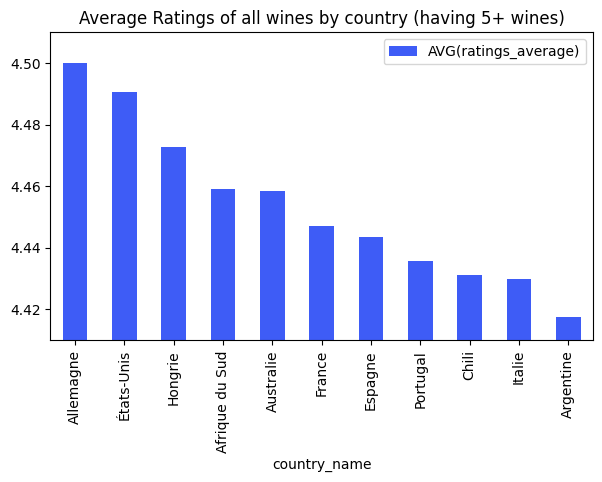

In [ ]:
## Wine average rating by country
with open("../queries/wine_average_by_country.sql") as f:
    query = f.read()
    
df = pd.read_sql_query(query, connexion)
df

df.plot(kind='bar', x='country_name', y='AVG(ratings_average)', ylim=(4.41, 4.51), figsize=(7, 4), color="#0D33F4", alpha=0.8, title="Average Ratings of all wines by country (having 5+ wines)")

<Axes: title={'center': 'Average Ratings of all vintages by Country (having 5+ vintages)'}, xlabel='country_name'>

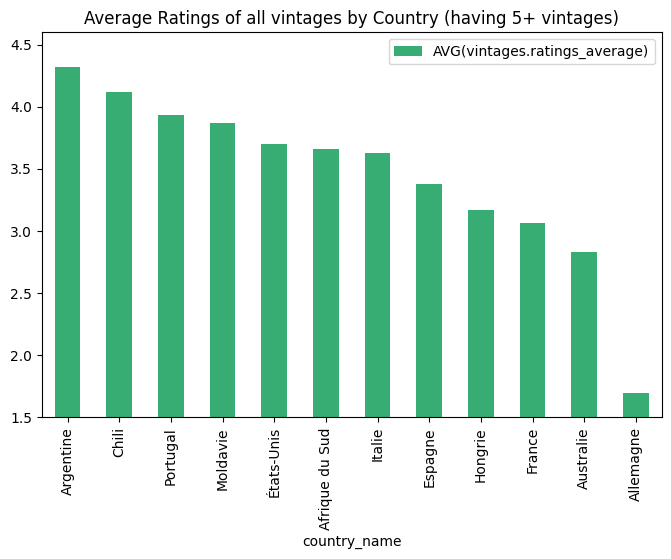

In [144]:
## Vintages average rating by country

with open("../queries/vintage_avg_by_country.sql") as f:
    query = f.read()
    
df = pd.read_sql_query(query, connexion)
df
df.plot(kind='bar', x='country_name', y='AVG(vintages.ratings_average)', ylim=(1.5, 4.6), figsize=(8, 5), color="#059951", alpha=0.8, title="Average Ratings of all vintages by Country (having 5+ vintages)")

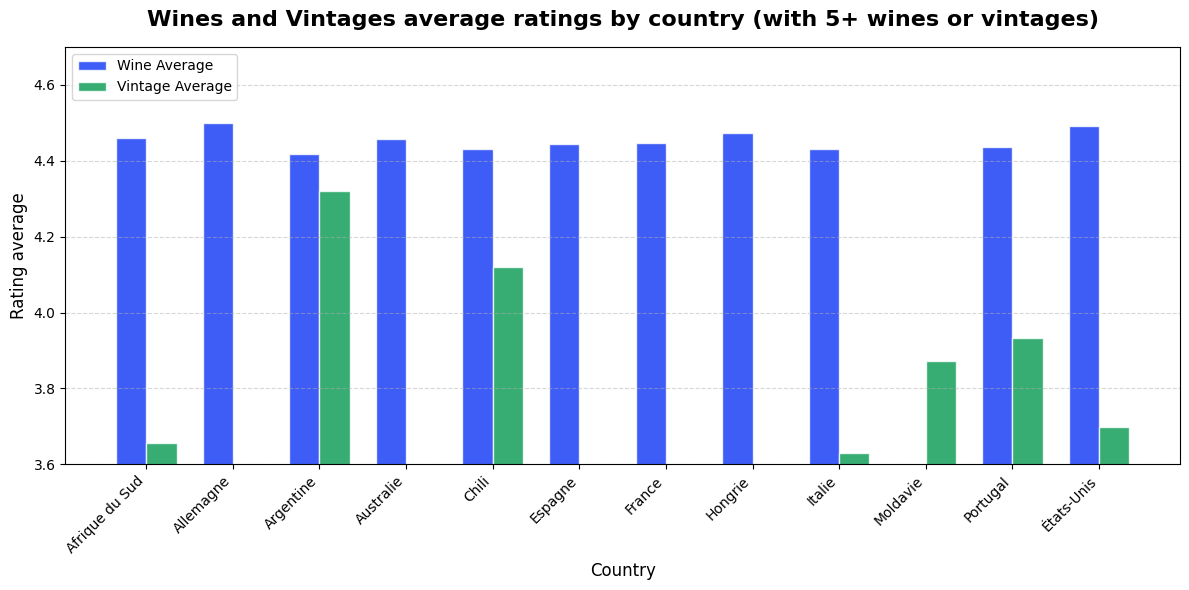

In [146]:
## Both graphs


import numpy as np


with open("../queries/wine_average_by_country.sql") as f:
    query = f.read()
df_wine = pd.read_sql_query(query, connexion)

with open("../queries/vintage_avg_by_country.sql") as f:
    query = f.read()
df_vint = pd.read_sql_query(query, connexion)

# Rename the average columns to simpler names
df_wine = df_wine.rename(columns={"AVG(ratings_average)": "wine_avg"})
df_vint = df_vint.rename(columns={"AVG(vintages.ratings_average)": "vintage_avg"})


# Merge both tables on country_name
df = pd.merge(df_wine, df_vint, on="country_name", how="outer")

# Replace missing values with 0 so countries missing in one query still appear
df = df.fillna(0)

# Optional: sort by country name
df = df.sort_values("country_name")

x = np.arange(len(df["country_name"]))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(
    x - width/2,
    df["wine_avg"],
    width=width,
    color="#0D33F4",
    edgecolor="white",
    alpha=0.8,
    label="Wine Average"
)

ax.bar(
    x + width/2,
    df["vintage_avg"],
    width=width,
    color="#059951",
    edgecolor="white",
    alpha=0.8,
    label="Vintage Average"
)

ax.set_title("Wines and Vintages average ratings by country (with 5+ wines or vintages)", fontsize=16, fontweight="bold", pad=15)
ax.set_xlabel("Country", fontsize=12)
ax.set_ylabel("Rating average", fontsize=12)

ax.set_xticks(x)
ax.set_xticklabels(df["country_name"], rotation=45, ha="right")
ax.grid(True, axis="y", linestyle="--", alpha=0.5)
ax.legend(loc="upper left", fontsize=10, frameon=True)
ax.set_ylim(3.6, 4.7)

fig.tight_layout()
plt.show()

### VIP recommendation
- One of our VIP client likes `Cabernet Sauvignon` and would like our top 5 recommendations. Which wines would you recommend to him?
query = (queries/vip_recommendation.sql)

Recommendations:

| Country | AVG Rating | vintage_name                      | price_euros | ratings_count | vintage_id | Region         |
|---------|------------|-----------------------------------|-------------|---------------|------------|----------------|
| US      | 4.8        | Scarecrow Cabernet Sauvignon 2015 | 1558.75     | 243           | 1384432    | Rutherford     |
| US      | 4.8        | Colgin IX Estate Red 2016         | 745.0       | 131           | 103459705  | Napa Valley    |
| Spain   | 4.8        | Artadi Viña El Pison 2018         | 437.5       | 64            | 156217121  | Vino de España |



In [158]:
%%sql
SELECT grape_id, grapes.name AS grape_name, regions.name AS region_name, regions.country_code, vintages.ratings_average, vintages.name AS vintage_name, vintages.price_euros, vintages.id AS vintage_id, vintages.ratings_count -- wines_count, ratings_count, wines.id,
FROM most_used_grapes_per_country
JOIN grapes on grapes.id = most_used_grapes_per_country.grape_id
JOIN regions on most_used_grapes_per_country.country_code = regions.country_code
JOIN wines on regions.id = wines.region_id
JOIN vintages on vintages.wine_id = wines.id
WHERE grape_id = 2 AND wines.ratings_count > 100
Order BY vintages.ratings_average DESC

Running query in 'sqlite:///../data/vivino.db'

grape_id,grape_name,region_name,country_code,ratings_average,vintage_name,price_euros,vintage_id,ratings_count
2,Cabernet Sauvignon,Napa Valley,us,4.8,Harlan Estate Harlan Estate Red 1998,1921.25,1384432,104
2,Cabernet Sauvignon,Rutherford,us,4.8,Scarecrow Cabernet Sauvignon 2015,1558.75,14187320,243
2,Cabernet Sauvignon,Napa Valley,us,4.8,Colgin IX Estate Red 2016,745.0,103459705,131
2,Cabernet Sauvignon,Vino de España,es,4.8,Artadi Viña El Pison 2018,437.5,156217121,64
2,Cabernet Sauvignon,Walla Walla Valley,us,4.7,Leonetti Cabernet Sauvignon 2006,201.25,114222,64
2,Cabernet Sauvignon,Ribera del Duero,es,4.7,Vega Sicilia Unico 2012,410.0,1515373,675
2,Cabernet Sauvignon,Ribera del Duero,es,4.7,Vega Sicilia Unico 2013,445.0,1845271,107
2,Cabernet Sauvignon,Ribera del Duero,es,4.7,Dominio de Pingus Pingus 2005,2327.5,3354001,290
2,Cabernet Sauvignon,Ribera del Duero,es,4.7,Dominio de Pingus Pingus 2004,3395.0,3358221,273
2,Cabernet Sauvignon,Napa Valley,us,4.7,Opus One Opus One 2015,1665.0,14117436,4948
